In [12]:
# Install necessary packages (run this only if you haven't installed them yet)
#!pip install copulas pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from copulas.bivariate import Clayton, Gumbel

# Load the dataset
file_path = "Wide_Sentiment_Data.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Select relevant topics for joint distribution analysis
selected_topics = ["Economy", "Freedom", "Liberty", "Democracy"]

# Convert all selected columns to numeric (handling any conversion issues)
df_selected = df[selected_topics].apply(pd.to_numeric, errors="coerce")

# Drop missing values
df_selected = df_selected.dropna()

# -------------------------------
# Convert data to uniform marginals using empirical CDF (for copula modeling)
# -------------------------------
df_copula = df_selected.copy()
for col in selected_topics:
    df_copula[col] = rankdata(df_copula[col]) / (len(df_copula) + 1)

# -------------------------------
# Copula-Based Dependency Analysis (Fixed)
# -------------------------------
copula_models = {
    "Clayton": Clayton(),
    "Gumbel": Gumbel()
}

copula_results = {}

for model_name, copula in copula_models.items():
    dependencies = {}
    for topic in selected_topics[1:]:  # Compare against Economy
        try:
            copula.fit(df_copula[["Economy", topic]].values)  # Use .values to ensure numpy format
            dependencies[topic] = copula.theta  # Correctly extract theta
        except Exception as e:
            dependencies[topic] = f"Error: {e}"  # Catch errors for debugging
    copula_results[model_name] = dependencies

# Convert results into a DataFrame
copula_df = pd.DataFrame(copula_results)

# Display copula dependency results
print("\nCopula-Based Dependency Metrics:")
print(copula_df)

# Save copula results as CSV
copula_df.to_csv("copula_dependency_metrics.csv")
print("Copula results saved as 'copula_dependency_metrics.csv'.")



Copula-Based Dependency Metrics:
            Clayton    Gumbel
Freedom    0.398370  1.199185
Liberty    0.374074  1.187037
Democracy  0.461299  1.230650
Copula results saved as 'copula_dependency_metrics.csv'.


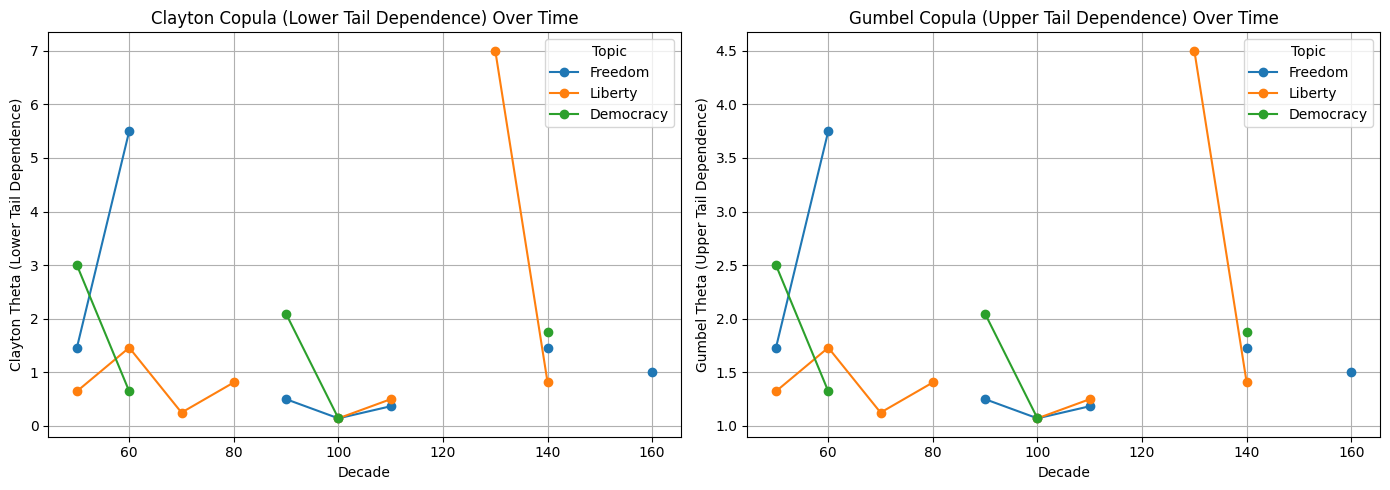

Results saved as 'copula_clayton_dependency_by_decade.csv' and 'copula_gumbel_dependency_by_decade.csv'.


In [13]:
# Install necessary packages (if needed)
#!pip install copulas pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from copulas.bivariate import Clayton, Gumbel

# Load the dataset
file_path = "Wide_Sentiment_Data.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Select relevant topics for joint distribution analysis
selected_topics = ["Economy", "Freedom", "Liberty", "Democracy"]

# Convert all selected columns to numeric (handling any conversion issues)
df_selected = df[selected_topics].apply(pd.to_numeric, errors="coerce")

# Drop missing values
df_selected = df_selected.dropna()

# Create a new "decade" column
df_selected["decade"] = (df_selected.index // 10) * 10

# Get unique decades
decades = sorted(df_selected["decade"].unique())

# -------------------------------
# Compute Copula Dependency Per Decade
# -------------------------------
copula_models = {"Clayton": Clayton, "Gumbel": Gumbel}
copula_results = {model: {topic: [] for topic in selected_topics[1:]} for model in copula_models}

for decade in decades:
    df_decade = df_selected[df_selected["decade"] == decade]

    # Convert to uniform marginals using empirical CDF
    df_copula = df_decade.copy()
    for col in selected_topics:
        df_copula[col] = rankdata(df_copula[col]) / (len(df_copula) + 1)

    # Fit copulas and store theta values
    for model_name, copula_class in copula_models.items():
        for topic in selected_topics[1:]:  # Compare against Economy
            try:
                copula = copula_class()
                copula.fit(df_copula[["Economy", topic]].values)  # Convert to numpy array
                copula_results[model_name][topic].append(copula.theta)  # Store theta for decade
            except Exception:
                copula_results[model_name][topic].append(None)  # Store None if an error occurs

# Convert results into DataFrames
copula_clayton_df = pd.DataFrame(copula_results["Clayton"], index=decades)
copula_gumbel_df = pd.DataFrame(copula_results["Gumbel"], index=decades)

# -------------------------------
# Plot Copula Dependency Trends
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Clayton Copula Trends (Lower Tail Dependence)
copula_clayton_df.plot(ax=axes[0], marker="o")
axes[0].set_title("Clayton Copula (Lower Tail Dependence) Over Time")
axes[0].set_xlabel("Decade")
axes[0].set_ylabel("Clayton Theta (Lower Tail Dependence)")
axes[0].legend(title="Topic")
axes[0].grid()

# Plot Gumbel Copula Trends (Upper Tail Dependence)
copula_gumbel_df.plot(ax=axes[1], marker="o")
axes[1].set_title("Gumbel Copula (Upper Tail Dependence) Over Time")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Gumbel Theta (Upper Tail Dependence)")
axes[1].legend(title="Topic")
axes[1].grid()

plt.tight_layout()
plt.savefig("copula_dependency_trends.png")
plt.show()

# Save results to CSV
copula_clayton_df.to_csv("copula_clayton_dependency_by_decade.csv")
copula_gumbel_df.to_csv("copula_gumbel_dependency_by_decade.csv")

print("Results saved as 'copula_clayton_dependency_by_decade.csv' and 'copula_gumbel_dependency_by_decade.csv'.")


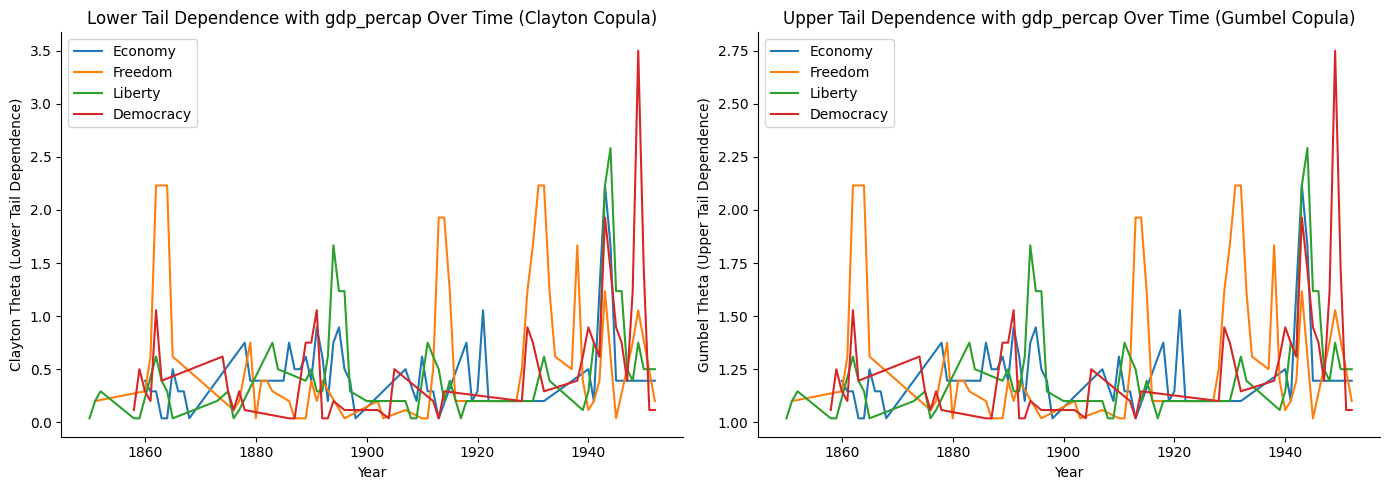

Results saved as 'copula_clayton_dependency_by_real_years.csv' and 'copula_gumbel_dependency_by_real_years.csv'.


In [30]:
# Install necessary packages (if needed)


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from copulas.bivariate import Clayton, Gumbel

# Load the dataset
file_path = "Wide_Sentiment_Data.csv"  # Replace with your actual file path
df = pd.read_csv(file_path)

# Ensure the 'year' column exists and set it as index
if 'year' in df.columns:
    df.set_index('year', inplace=True)

# Select relevant topics for joint distribution analysis
selected_topics = ["gdp_percap","Economy", "Freedom", "Liberty", "Democracy"]

# Convert all selected columns to numeric (handling any conversion issues)
df_selected = df[selected_topics].apply(pd.to_numeric, errors="coerce")

# Drop missing values
df_selected = df_selected.dropna()

# -------------------------------
# Compute Copula Dependency Over Time Using Original Years
# -------------------------------
rolling_window = 10  # Rolling window in years

# Dictionaries to store copula results per year
copula_results_clayton = {topic: [] for topic in selected_topics[1:]}
copula_results_gumbel = {topic: [] for topic in selected_topics[1:]}
years_list = []

for year in df_selected.index[:-rolling_window]:  # Use real years
    df_window = df_selected.loc[year:year + rolling_window]

    # Convert to uniform marginals using empirical CDF
    df_copula = df_window.copy()
    for col in selected_topics:
        df_copula[col] = rankdata(df_copula[col]) / (len(df_copula) + 1)

    # Store actual year instead of midpoint
    years_list.append(year)

    # Fit copulas separately and store results
    for topic in selected_topics[1:]:  # Compare against Economy
        try:
            # Clayton Copula
            clayton_copula = Clayton()
            clayton_copula.fit(df_copula[["gdp_percap", topic]].values)
            copula_results_clayton[topic].append(clayton_copula.theta)
        except Exception:
            copula_results_clayton[topic].append(None)

        try:
            # Gumbel Copula
            gumbel_copula = Gumbel()
            gumbel_copula.fit(df_copula[["gdp_percap", topic]].values)
            copula_results_gumbel[topic].append(gumbel_copula.theta)
        except Exception:
            copula_results_gumbel[topic].append(None)

# Convert results into DataFrames with real years as index
copula_clayton_df = pd.DataFrame(copula_results_clayton, index=years_list)
copula_gumbel_df = pd.DataFrame(copula_results_gumbel, index=years_list)

# -------------------------------
# Interpolate Missing Values for Smoother Trends
# -------------------------------
copula_clayton_df = copula_clayton_df.interpolate(method='linear')
copula_gumbel_df = copula_gumbel_df.interpolate(method='linear')

# -------------------------------
# Plot Copula Dependency Trends Over Time
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Clayton Copula Trends (Lower Tail Dependence)
copula_clayton_df.plot(ax=axes[0])
axes[0].set_title("Lower Tail Dependence with gdp_percap Over Time (Clayton Copula)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Clayton Theta (Lower Tail Dependence)")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Plot Gumbel Copula Trends (Upper Tail Dependence)
copula_gumbel_df.plot(ax=axes[1])
axes[1].set_title("Upper Tail Dependence with gdp_percap Over Time (Gumbel Copula)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Gumbel Theta (Upper Tail Dependence)")
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("copula_dependency_trends_real_years.png")
plt.show()

# Save results to CSV
copula_clayton_df.to_csv("copula_clayton_dependency_by_real_years.csv")
copula_gumbel_df.to_csv("copula_gumbel_dependency_by_real_years.csv")

print("Results saved as 'copula_clayton_dependency_by_real_years.csv' and 'copula_gumbel_dependency_by_real_years.csv'.")


In [27]:
df.head()

,Democracy,Economy,Freedom,Liberty,Life_expectancy,democracy_frequency,economy_frequency,equality_frequency,freedom_frequency,gdp_percap,justice_frequency,liberty_frequency
year,,,,,,,,,,,,
1800,NaN,NaN,NaN,NaN,NaN,0.000004,0.000018,0.000014,0.000050,NaN,0.000142,0.000132
1801,NaN,NaN,NaN,NaN,NaN,0.000004,0.000018,0.000014,0.000050,NaN,0.000144,0.000133
1802,NaN,NaN,NaN,NaN,NaN,0.000004,0.000018,0.000014,0.000051,NaN,0.000147,0.000134
1803,NaN,NaN,NaN,NaN,NaN,0.000004,0.000018,0.000014,0.000051,NaN,0.000151,0.000134
1804,NaN,NaN,NaN,NaN,NaN,0.000004,0.000019,0.000014,0.000052,NaN,0.000155,0.000134


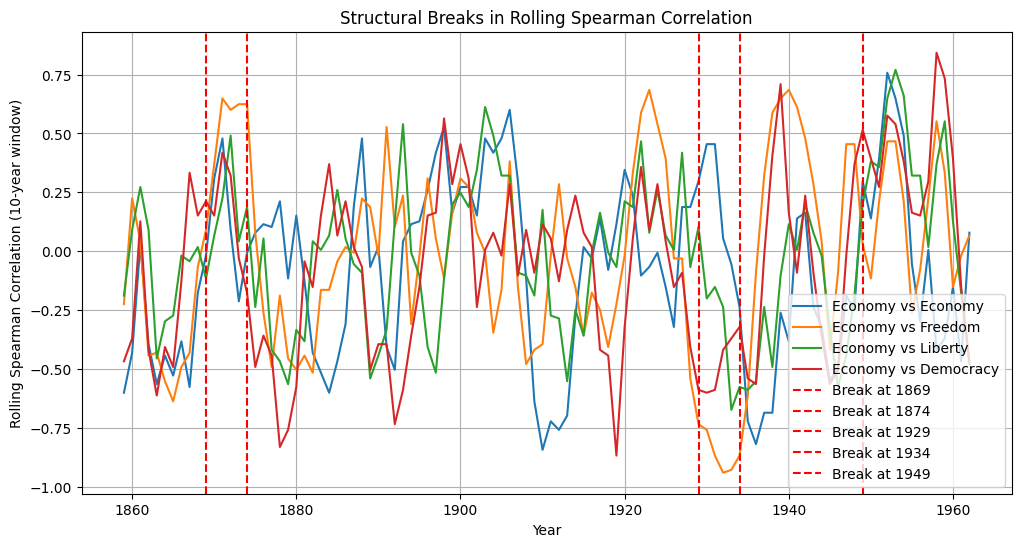

Results saved as 'spearman_regime_switching.png' and 'spearman_structural_breaks.csv'.


In [29]:
# Install necessary packages (run if needed)
#!pip install ruptures pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from scipy.stats import spearmanr

# Load the dataset
file_path = "Wide_Sentiment_Data.csv"  # Update with actual path if necessary
df = pd.read_csv(file_path)

# Ensure 'year' is the index
df.set_index("year", inplace=True)

# Select relevant topics
selected_topics = ["gdp_percap", "Economy", "Freedom", "Liberty", "Democracy"]
df_selected = df[selected_topics].dropna()

# Compute rolling Spearman correlation
def rolling_correlation(df, method="spearman", window=10):
    rolling_corrs = pd.DataFrame(index=df.index, columns=df.columns[1:])
    for i in range(len(df) - window + 1):
        df_window = df.iloc[i : i + window]
        for topic in df.columns[1:]:
            corr, _ = spearmanr(df_window["gdp_percap"], df_window[topic])
            rolling_corrs.loc[df.index[i + window - 1], topic] = corr
    return rolling_corrs.astype(float)

rolling_spearman_10 = rolling_correlation(df_selected, method="spearman", window=10)

# Convert data to numpy array for change point detection
rolling_spearman_np = rolling_spearman_10.dropna().values

# Detect structural breaks
algo = rpt.Binseg(model="l2").fit(rolling_spearman_np)
change_points = algo.predict(n_bkps=5)  # Detect 5 structural breaks

# Convert change points to actual years
change_years = rolling_spearman_10.dropna().index[change_points[:-1]]

# Plot rolling Spearman correlation with structural breaks
plt.figure(figsize=(12, 6))
for topic in rolling_spearman_10.columns:
    plt.plot(rolling_spearman_10.index, rolling_spearman_10[topic], label=f"Economy vs {topic}")

# Mark structural breakpoints
for year in change_years:
    plt.axvline(x=year, color="r", linestyle="--", label=f"Break at {year}")

plt.xlabel("Year")
plt.ylabel("Rolling Spearman Correlation (10-year window)")
plt.title("Structural Breaks in Rolling Spearman Correlation")
plt.legend()
plt.grid()
plt.savefig("spearman_regime_switching.png")
plt.show()

# Save detected structural breakpoints
breakpoints_df = pd.DataFrame({"Breakpoints": change_years})
breakpoints_df.to_csv("spearman_structural_breaks.csv", index=False)

print("Results saved as 'spearman_regime_switching.png' and 'spearman_structural_breaks.csv'.")


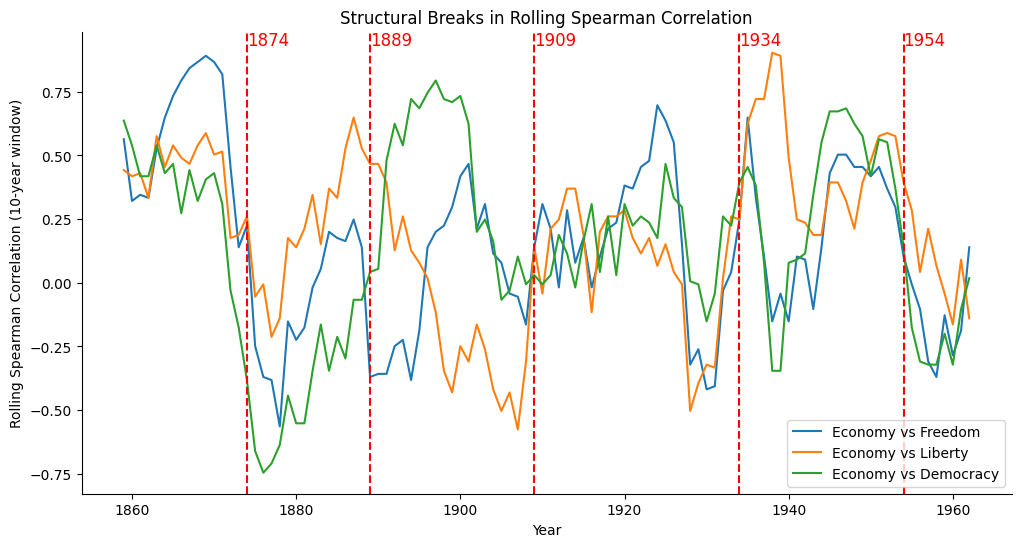

Results saved as 'spearman_regime_switching.png' and 'spearman_structural_breaks.csv'.


In [26]:
# Install necessary packages (run if needed)
# !pip install ruptures pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from scipy.stats import spearmanr

# Load the dataset
file_path = "Wide_Sentiment_Data.csv"  # Update with actual path if necessary
df = pd.read_csv(file_path)

# Ensure 'year' is the index
df.set_index("year", inplace=True)

# Select relevant topics
selected_topics = ["Economy", "Freedom", "Liberty", "Democracy"]
df_selected = df[selected_topics].dropna()

# Compute rolling Spearman correlation
def rolling_correlation(df, method="spearman", window=10):
    rolling_corrs = pd.DataFrame(index=df.index, columns=df.columns[1:])
    for i in range(len(df) - window + 1):
        df_window = df.iloc[i : i + window]
        for topic in df.columns[1:]:
            corr, _ = spearmanr(df_window["Economy"], df_window[topic])
            rolling_corrs.loc[df.index[i + window - 1], topic] = corr
    return rolling_corrs.astype(float)

rolling_spearman_10 = rolling_correlation(df_selected, method="spearman", window=10)

# Convert data to numpy array for change point detection
rolling_spearman_np = rolling_spearman_10.dropna().values

# Detect structural breaks
algo = rpt.Binseg(model="l2").fit(rolling_spearman_np)
change_points = algo.predict(n_bkps=5)  # Detect 5 structural breaks

# Convert change points to actual years
change_years = rolling_spearman_10.dropna().index[change_points[:-1]]

# Plot rolling Spearman correlation with structural breaks
plt.figure(figsize=(12, 6))

# Plot rolling correlations for each topic
for topic in rolling_spearman_10.columns:
    plt.plot(rolling_spearman_10.index, rolling_spearman_10[topic], label=f"Economy vs {topic}")

# Mark structural breakpoints with vertical lines and year labels
for year in change_years:
    plt.axvline(x=year, color="r", linestyle="--")
    plt.text(year, plt.ylim()[1], str(year), color="r", fontsize=12, ha="left", va="top")

# Formatting: No grid, no spines
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


plt.xlabel("Year")
plt.ylabel("Rolling Spearman Correlation (10-year window)")
plt.title("Structural Breaks in Rolling Spearman Correlation")
plt.legend()
plt.savefig("spearman_regime_switching.png")
plt.show()

# Save detected structural breakpoints
breakpoints_df = pd.DataFrame({"Breakpoints": change_years})
breakpoints_df.to_csv("spearman_structural_breaks.csv", index=False)

print("Results saved as 'spearman_regime_switching.png' and 'spearman_structural_breaks.csv'.")


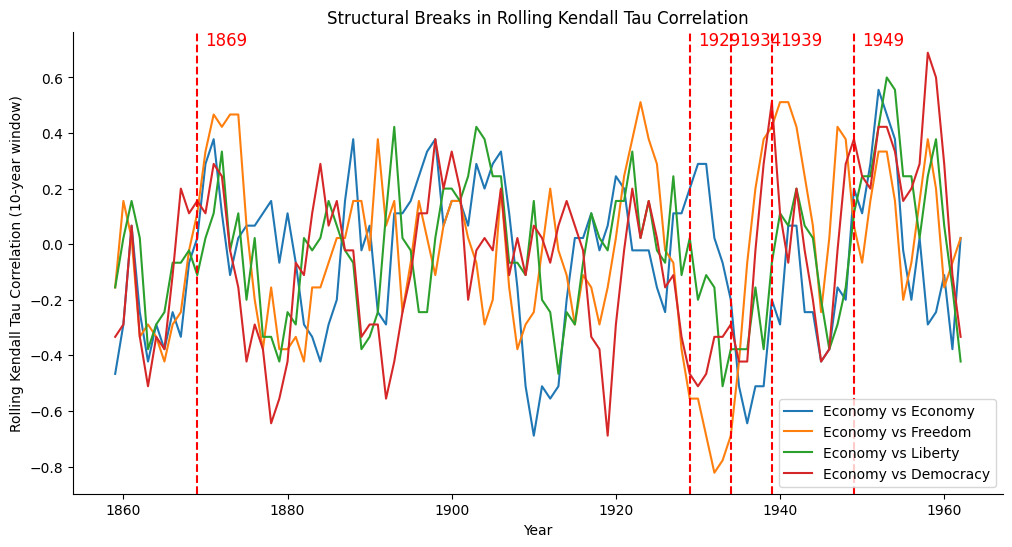

Results saved as 'kendall_regime_switching.png' and 'kendall_structural_breaks.csv'.


In [31]:
# Install necessary packages (run if needed)
# !pip install ruptures pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from scipy.stats import kendalltau

# Compute rolling Kendall Tau correlation
def rolling_correlation(df, method="kendall", window=10):
    rolling_corrs = pd.DataFrame(index=df.index, columns=df.columns[1:])
    for i in range(len(df) - window + 1):
        df_window = df.iloc[i : i + window]
        for topic in df.columns[1:]:
            corr, _ = kendalltau(df_window["gdp_percap"], df_window[topic])
            rolling_corrs.loc[df.index[i + window - 1], topic] = corr
    return rolling_corrs.astype(float)

rolling_kendall_10 = rolling_correlation(df_selected, method="kendall", window=10)

# Convert data to numpy array for change point detection
rolling_kendall_np = rolling_kendall_10.dropna().values

# Detect structural breaks
algo_kendall = rpt.Binseg(model="l2").fit(rolling_kendall_np)
change_points_kendall = algo_kendall.predict(n_bkps=5)  # Detect 5 structural breaks

# Convert change points to actual years
change_years_kendall = rolling_kendall_10.dropna().index[change_points_kendall[:-1]]

# Plot rolling Kendall Tau correlation with structural breaks
plt.figure(figsize=(12, 6))

# Plot rolling correlations for each topic
for topic in rolling_kendall_10.columns:
    plt.plot(rolling_kendall_10.index, rolling_kendall_10[topic], label=f"Economy vs {topic}")

# Mark structural breakpoints with vertical lines and year labels (aligned to the right)
for year in change_years_kendall:
    plt.axvline(x=year, color="r", linestyle="--")
    plt.text(year + 1, plt.ylim()[1], str(year), color="r", fontsize=12, ha="left", va="top")

# Formatting: No grid, no spines
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


plt.xlabel("Year")
plt.ylabel("Rolling Kendall Tau Correlation (10-year window)")
plt.title("Structural Breaks in Rolling Kendall Tau Correlation")
plt.legend()
plt.savefig("kendall_regime_switching.png")
plt.show()

# Save detected structural breakpoints
breakpoints_kendall_df = pd.DataFrame({"Breakpoints": change_years_kendall})
breakpoints_kendall_df.to_csv("kendall_structural_breaks.csv", index=False)

print("Results saved as 'kendall_regime_switching.png' and 'kendall_structural_breaks.csv'.")


Animation saved at: sentiment_joint_distribution_animation.gif


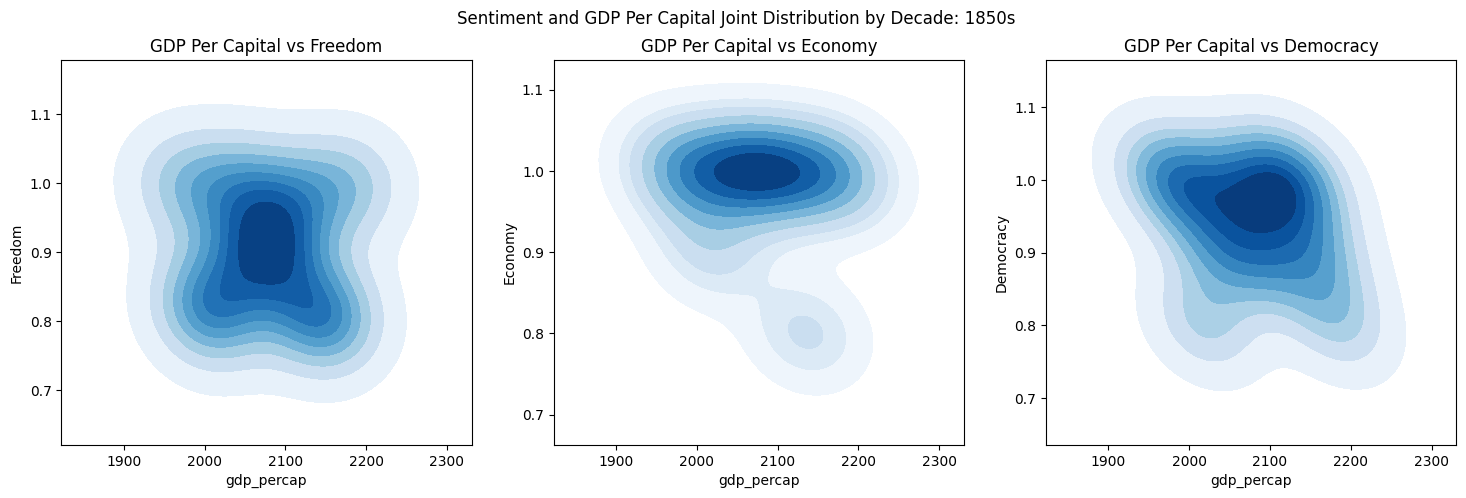

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation



# Select relevant topics for joint distribution analysis
selected_topics = ["Economy", "Freedom", "gdp_percap", "Democracy"]

# Convert all selected columns to numeric (handling any conversion issues)
df_selected = df[selected_topics].apply(pd.to_numeric, errors="coerce")

# Drop missing values
df_selected = df_selected.dropna()

# Create a new column for decades
df_selected["decade"] = (df_selected.index // 10) * 10

# Get unique decades
decades = sorted(df_selected["decade"].unique())

# Set up the figure for animation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
topic_pairs = [("gdp_percap", "Freedom"), ("gdp_percap", "Economy"), ("gdp_percap", "Democracy")]

# Function to update the animation for each decade
def update(frame):
    decade = decades[frame]
    df_decade = df_selected[df_selected["decade"] == decade]

    # Clear previous plots
    for ax in axes:
        ax.clear()

    for ax, (x_var, y_var) in zip(axes, topic_pairs):
        sns.kdeplot(
            x=df_decade[x_var],
            y=df_decade[y_var],
            fill=True,
            cmap="Blues",
            ax=ax
        )
        ax.set_xlabel(x_var)
        ax.set_ylabel(y_var)
        ax.set_title(f"GDP Per Capital vs {y_var}")

    plt.suptitle(f"Sentiment and GDP Per Capital Joint Distribution by Decade: {decade}s")

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(decades), repeat=True)

# Save the animation as a video file
animation_path = "sentiment_joint_distribution_animation.gif"
ani.save(animation_path, writer="pil", fps=1)

print(f"Animation saved at: {animation_path}")
